# Mobile App Rating Prediction using Machine Learning

## Objective

- This project aims to build a machine learning model that predicts the rating of mobile applications on the Google Play Store. By analyzing features such as number of installs, reviews, app size, price, and category, the model attempts to estimate how users are likely to rate an application.

- Predicting app ratings can help developers understand the factors that influence user satisfaction and improve application quality before release.

## Project Goals

- Clean the dataset by handling missing values and incorrect formats.
- Perform Exploratory Data Analysis (EDA) to understand feature relationships.
- Create visualizations to identify patterns in the data.
- Train machine learning models to predict app ratings.
- Evaluate model performance.
- Derive insights about factors influencing app ratings.

## 1. Initial Data Exploration

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"D:\Mobile App Rating Prediction\data\googleplaystore.csv")
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
df.shape

(10841, 13)

In [6]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  int64  
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10841 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10839 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.1+ MB


In [8]:
df.describe()

,Rating,Reviews
count,9367.000000,1.084100e+04
mean,4.191513,4.441119e+05
std,0.515735,2.927629e+06
min,1.000000,0.000000e+00
25%,4.000000,3.800000e+01
50%,4.300000,2.094000e+03
75%,4.500000,5.476800e+04
max,5.000000,7.815831e+07


In [9]:
df.isnull().sum()

App                  0
Category             1
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               1
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

## 2. Data Preprocessing

### Reordering Columns

- For better clarity during model training, the target variable **Rating** is moved to the end of the dataset.

In [10]:
cols = [col for col in df.columns if col != "Rating"] + ["Rating"]
df = df[cols]

df.head()

,App,Category,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Rating
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,4.1
1,Coloring book moana,ART_AND_DESIGN,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,3.9
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,4.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,4.5
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,4.3


### Handling Missing Values in Rating

- The **Rating** column is the target variable of this project. Rows where the rating is missing cannot be used for model training. Therefore, rows with missing ratings are removed.

In [11]:
df = df.dropna(subset=['Rating'])

df['Rating'].isnull().sum()

np.int64(0)

### Convert Reviews to Numeric

- The **Reviews** column represents the number of user reviews for each app. Since it is stored as a string, it must be converted into numeric format for analysis and modeling.

In [12]:
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

### Cleaning the Installs Column

- The **Installs** column contains symbols such as commas and plus signs (e.g., 10,000+). These symbols must be removed so the column can be converted into numeric format.

In [13]:
df['Installs'] = df['Installs'].str.replace(',', '')
df['Installs'] = df['Installs'].str.replace('+', '')
df['Installs'] = df['Installs'].astype(int)

### Cleaning the Price Column

- The **Price** column contains dollar symbols (e.g., $4.99). The dollar symbol must be removed before converting the values into numeric format.

In [14]:
df['Price'] = df['Price'].str.replace('$', '')
df['Price'] = df['Price'].astype(float)

### Cleaning the Size Column

- The **Size** column contains values with units such as "M" (megabytes) and sometimes text like "Varies with device". The unit symbols are removed and values are converted to numeric format where possible.

In [15]:
df['Size'] = df['Size'].str.replace('M','')
df['Size'] = df['Size'].str.replace('k','')
df['Size'] = df['Size'].replace('Varies with device', np.nan)

df['Size'] = pd.to_numeric(df['Size'], errors='coerce')

### Converting Last Updated Column

- The **Last Updated** column represents the date when the application was last updated. This column is converted into a datetime format to make it easier to analyze time-based patterns.

In [16]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

### Handling Remaining Missing Values

- Missing values in numerical columns are filled using the median value. The median is used because it is less sensitive to extreme values.

In [ ]:
df['Size'].fillna(df['Size'].median(), inplace=True)
df['Reviews'].fillna(df['Reviews'].median(), inplace=True)

In [18]:
df.head()

,App,Category,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Rating
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,4.1
1,Coloring book moana,ART_AND_DESIGN,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,3.9
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,4.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,4.5
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,4.3


In [19]:
df = df.dropna()
df.isnull().sum()

App               0
Category          0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
Rating            0
dtype: int64

### Final Dataset Shape After Cleaning

- After removing rows with missing values and cleaning the dataset, we check the final dataset shape.

In [20]:
df.shape

(9360, 13)

### Saving the Cleaned Dataset

- After completing the preprocessing steps such as handling missing values, cleaning numeric columns, and converting data types, the cleaned dataset is saved as a new CSV file inside the `data` folder. 
- This allows the processed dataset to be reused for future analysis or model training without repeating the preprocessing steps.

In [ ]:
df.to_csv("D:\Mobile App Rating Prediction\data\cleaned_googleplaystoredataset.csv", index=False)

## Observations After Data Preprocessing

After completing the preprocessing steps, the dataset has been cleaned and prepared for analysis and machine learning. The following key changes were made:

- Some missing numeric values were handled by **replacing them with the median**, ensuring minimal impact from outliers.
- A small number of remaining rows with missing categorical values were **removed from the dataset**.
- Columns such as **Reviews, Installs, Price, and Size** were converted into numeric format so they can be used in machine learning models.
- Symbols such as **commas (+), dollar signs ($), and size units (M, k)** were removed to standardize numeric values.
- The **Last Updated** column was converted into datetime format for better handling of date information.
- The **Rating** column was moved to the end of the dataset to clearly represent it as the target variable.

After preprocessing, the dataset is now clean, consistent, and suitable for performing exploratory data analysis and training machine learning models.

## 3. Exploratory Data Analysis (EDA)

### Distribution of App Ratings

This plot shows the distribution of ratings across all applications in the dataset. It helps identify whether most apps receive high ratings or if ratings are evenly distributed.

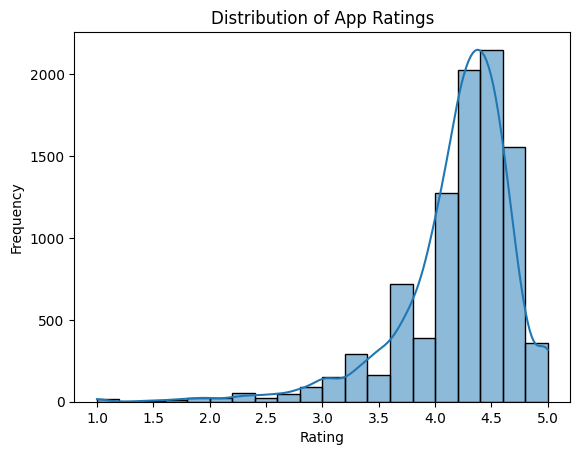

In [74]:
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

- Most applications have ratings between **4.0 and 4.5**, indicating that the majority of apps on the Play Store receive relatively positive user feedback.

### Relationship Between Reviews and Rating

The number of reviews indicates how many users have rated or commented on an application. This visualization helps understand whether apps with more reviews tend to have higher ratings.

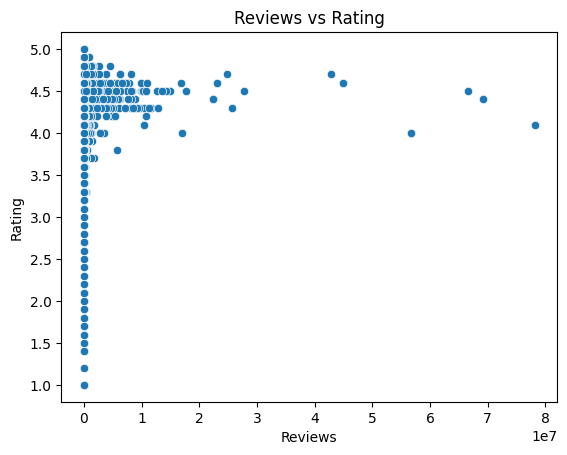

In [75]:
sns.scatterplot(x='Reviews', y='Rating', data=df)
plt.title("Reviews vs Rating")
plt.show()

- Apps with a larger number of reviews tend to maintain ratings around the 4.0–4.5 range, suggesting that popular apps generally sustain good user satisfaction.

### Correlation Heatmap

A correlation heatmap helps identify relationships between numerical variables in the dataset. Strong correlations may indicate features that influence app ratings.

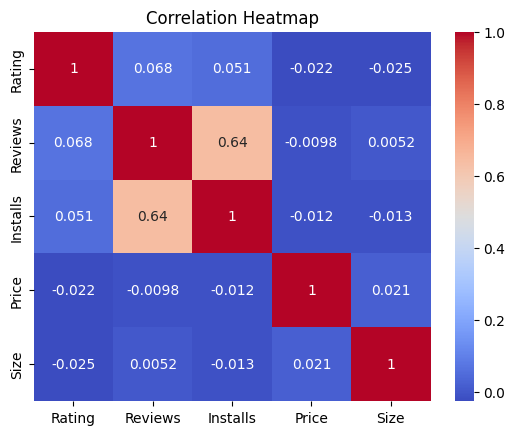

In [ ]:
numeric_df = df[['Rating','Reviews','Installs','Price','Size']]
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

- The correlation heatmap shows that **Reviews and Installs have a strong positive correlation (0.64)**, indicating that applications with more installs tend to receive more user reviews.

- However, the correlation between **Rating and other numerical features such as Reviews, Installs, Price, and Size is relatively weak**, suggesting that app ratings may depend more on qualitative factors such as user experience, app functionality, and category rather than purely numerical attributes.

### Top 10 Categories by Total Installs

Different application categories attract varying levels of user demand. By aggregating the total number of installs across categories, we can identify which categories dominate the mobile application market in terms of popularity and user reach.

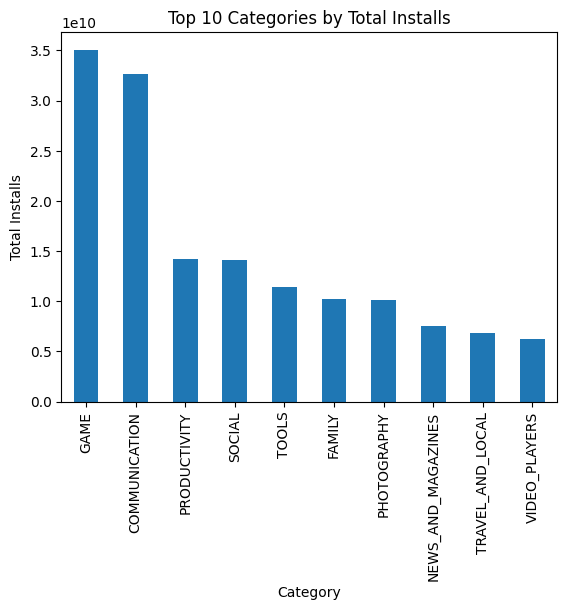

In [ ]:
top_installs = df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)
top_installs.plot(kind='bar')
plt.title("Top 10 Categories by Total Installs")
plt.ylabel("Total Installs")
plt.show()

- The visualization shows that certain categories dominate the Google Play Store in terms of total installs. Categories such as **GAME, COMMUNICATION, and PRODUCTIVITY** typically receive the highest number of installs, indicating strong user engagement and demand in these areas.

- This suggests that entertainment and communication-based applications attract a larger user base compared to other categories.

## Key Insights from EDA

From the exploratory analysis, several patterns were observed:

- Most apps on the Play Store have ratings between 4.0 and 4.5.
- Applications with higher installs and reviews tend to maintain stable ratings.
- Some app categories like Game, Communication, etc consistently receive higher ratings than others.

These insights help identify which features may influence app ratings and will guide the machine learning modeling process.

## 4. Machine Learning Model Training and Evaluation

In this step, we train regression models to predict mobile application ratings using the available features.

The following steps are performed:

1. Encode categorical variables so that machine learning algorithms can process them.
2. Define the feature variables (X) and the target variable (y).
3. Split the dataset into training and testing sets.
4. Train two regression models:
   - Linear Regression
   - Random Forest Regressor
5. Evaluate the models using performance metrics:
   - R² Score
   - Mean Absolute Error (MAE)
   - Mean Squared Error (MSE)

These metrics help determine how accurately the models can predict app ratings.

In [93]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

le = LabelEncoder()

categorical_cols = ['Category','Type','Content Rating','Genres','Current Ver','Android Ver']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Defining features and target variable
X = df.drop(["Rating", "App", "Last Updated"], axis=1)
Y = df["Rating"]

# Splitting dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Training Linear Regression model
lr = LinearRegression()
lr.fit(X_train, Y_train)
Y_pred_lr = lr.predict(X_test)

# Training Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)
Y_pred_rf = rf.predict(X_test)

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [
        r2_score(Y_test, Y_pred_lr),
        r2_score(Y_test, Y_pred_rf)
    ],
    "MAE": [
        mean_absolute_error(Y_test, Y_pred_lr),
        mean_absolute_error(Y_test, Y_pred_rf)
    ],
    "MSE": [
        mean_squared_error(Y_test, Y_pred_lr),
        mean_squared_error(Y_test, Y_pred_rf)
    ]
})
print(comparison)

# Determine best model based on R2 score
best_model = comparison.loc[comparison["R2 Score"].idxmax(), "Model"]
print("\nBest Performing Model:", best_model)

               Model  R2 Score       MAE       MSE
0  Linear Regression  0.128845  0.324509  0.225081
1      Random Forest  0.177646  0.301649  0.212472

Best Performing Model: Random Forest


In [100]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# tolerance for accuracy calculation
tolerance = 0.5

# Accuracy calculation
accuracy_lr = np.mean(np.abs(Y_test - Y_pred_lr) <= tolerance)
accuracy_rf = np.mean(np.abs(Y_test - Y_pred_rf) <= tolerance)

# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [
        r2_score(Y_test, Y_pred_lr),
        r2_score(Y_test, Y_pred_rf)
    ],
    "MAE": [
        mean_absolute_error(Y_test, Y_pred_lr),
        mean_absolute_error(Y_test, Y_pred_rf)
    ],
    "MSE": [
        mean_squared_error(Y_test, Y_pred_lr),
        mean_squared_error(Y_test, Y_pred_rf)
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf
    ]
})

# Display table
print("Model Performance Comparison:\n")
print(comparison)

# Determine best model based on R2 Score
best_model = comparison.loc[comparison["R2 Score"].idxmax(), "Model"]

print("\nBest Performing Model:", best_model)

Model Performance Comparison:

               Model  R2 Score       MAE       MSE  Accuracy
0  Linear Regression  0.128845  0.324509  0.225081  0.804487
1      Random Forest  0.177646  0.301649  0.212472  0.800214

Best Performing Model: Random Forest


## Model Performance Insight

The performance of Linear Regression and Random Forest models was evaluated using R² Score, Mean Absolute Error (MAE), and Mean Squared Error (MSE).

From the comparison results, the Random Forest model achieved a higher R² score and lower error values compared to Linear Regression, indicating better predictive performance.

The Random Forest model was therefore selected as the best-performing model for this task. Random Forest performs well for structured datasets because it can capture complex nonlinear relationships between features, whereas Linear Regression assumes a simple linear relationship between the input variables and the target variable.

However, the overall R² score remains relatively low. This is expected because mobile app ratings are influenced by many qualitative factors such as user experience, interface design, application performance, and user expectations, which are not captured in the dataset.

### Actual vs Predicted Ratings

To evaluate the model's predictive capability, a scatter plot is created comparing the actual app ratings with the predicted ratings from the Random Forest model.

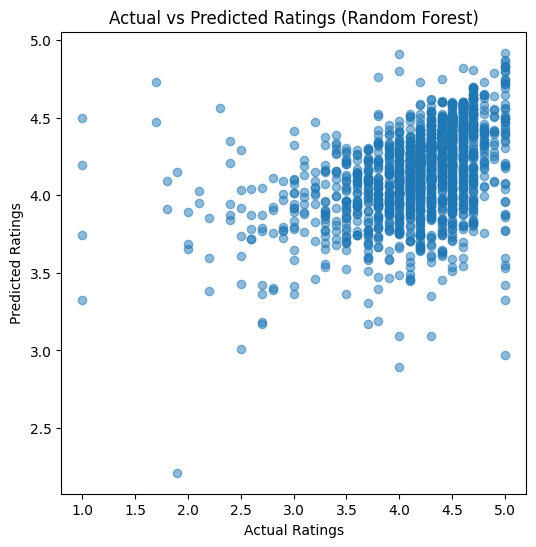

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(Y_test, Y_pred_rf, alpha=0.5)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings (Random Forest)")
plt.show()

### Residual Analysis

Residuals represent the difference between the actual and predicted values. Analyzing residuals helps determine whether the model is systematically over-predicting or under-predicting ratings.

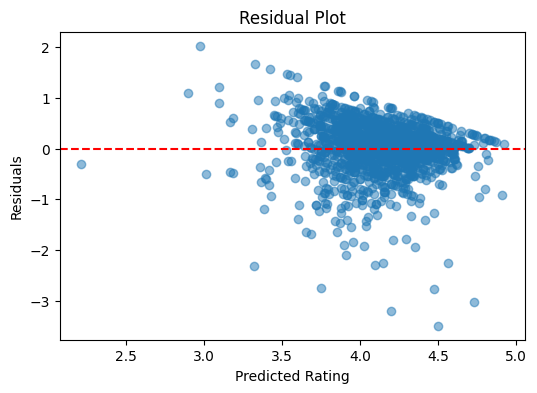

In [104]:
residuals = Y_test - Y_pred_rf

plt.figure(figsize=(6,4))
plt.scatter(Y_pred_rf, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Rating")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

## Conclusion

This project developed a machine learning pipeline to predict mobile application ratings using the Google Play Store dataset. The workflow included data preprocessing, exploratory data analysis, feature encoding, and model training.

Two regression models were evaluated, with Random Forest demonstrating better predictive performance compared to Linear Regression. The model was able to capture certain patterns between app characteristics such as installs, reviews, category, and ratings.

However, the moderate R² score suggests that app ratings are influenced by many qualitative factors such as usability, design quality, and application stability, which are not captured in the dataset. Despite this limitation, the project demonstrates a complete end-to-end machine learning workflow and highlights how structured data can be used to build predictive models for real-world applications.